## Titanic Survival Analysis 

    ## Phase 1 : Setup & Data Loading 


In [2]:
# Import Libraries 
import pandas as pd                  
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 

In [3]:
# Load the Data 

data = pd.read_csv("C:\\Users\\ASUS\\OneDrive\\Desktop\\DataScience\\Projects_self\\project_02\\Titanic-Dataset.csv")

# Check the top 5 data
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# check the shape of the data 
print("Shape of the data :",data.shape)

# Check the data info 
print("Data Info we have:")
data.info()

Shape of the data : (891, 12)
Data Info we have:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


    ## What we DiD in Phase 1 ?
    . We imported the libraries.
    . Looaded the data.
    . Checked the info, shape, top 5 data. 

## #Phase 2 : Data exploration(before cleaning)

In [5]:
# Checking Missing value count
missing_value = data.isnull().sum()
missing_value

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# checking missing values in percentage 
missing_value_percentage = (missing_value/len(data))*100
missing_value_percentage.round(2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

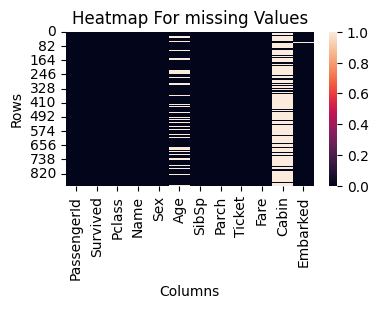

In [30]:
# Missing values heatmap 
plt.figure(figsize=(4,2))
sns.heatmap(data.isnull())
plt.title("Heatmap For missing Values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [8]:
# Basic Statistics 

data.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [9]:
# Unique value count for key columns 
# Column1 : Survived 
value_cnt_Survived = data["Survived"].value_counts()
value_cnt_Survived

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
# Unique value count for key columns 
# Column2 : Pclass
value_cnt_Pclass = data["Pclass"].value_counts()
value_cnt_Pclass

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [11]:
# Unique value count for key columns 
# Column3 : Age
value_cnt_Age = data["Age"].value_counts()
value_cnt_Age

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [12]:
# Unique value count for key columns 
# Colume4: Sex 
value_cnt_Sex = data["Sex"].value_counts()
value_cnt_Sex

Sex
male      577
female    314
Name: count, dtype: int64

In [13]:
# Unique value count for key columns 
# Colume5: Embarked 
value_cnt_Embarked = data["Embarked"].value_counts()
value_cnt_Embarked

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

    ## What we did In phase 2 
    - checked missing values/ missing values percentage using (.isnull().sum() & sns heatmap)
    - checked Basic Statistics for (min,max,mean,count etc)
    - checked Unique value counts of necessary columns    

## Phase3 : Data Cleaning
- fix missing values & verify results

In [14]:
# Make the copy of origional data 

data_work = data.copy()

# Match the conditions for furthur 
shape1 = data.shape
shape2 = data_work.shape

# conditions
if shape1 == shape2 :
    print("Shape match, Go ahead !!!")
else:
    print("Shape didn't match, check the code above.")

Shape match, Go ahead !!!


In [15]:
# Fill the Age with Median 

age_missing = data_work["Age"].isnull().sum()

print("Before data filling of age, missing values :", age_missing)

age_fill =  data_work["Age"].median()
data_work["Age"] =  data_work["Age"].fillna(age_fill)

print("After data filling of age, missing values:", data_work["Age"].isnull().sum())

Before data filling of age, missing values : 177
After data filling of age, missing values: 0


In [16]:
# Drop Cabin as 77% values missing, too high to fill reliability
drop_cabin = data_work.drop(columns=["Cabin"], inplace= True)

# Check the shape of ther drop
before_drop = shape2
after_drop = data_work.shape

print("Shape before drop :", before_drop)
print("Shape After drop: ", after_drop)


Shape before drop : (891, 12)
Shape After drop:  (891, 11)


In [17]:
data_work.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [18]:
# fill the Embarked with mode 
print("Missing value of embark before fill :",data_work["Embarked"].isnull().sum())

fill_embark = data_work["Embarked"].mode()[0]
data_work["Embarked"] = data_work["Embarked"].fillna(fill_embark)

print('Missing value of embarked after cleaning :', data_work["Embarked"].isnull().sum())


Missing value of embark before fill : 2
Missing value of embarked after cleaning : 0


    ## Final verification of data cleaning 
    - missing value should be 0
    - sns heatmap fully empty

In [19]:
# Final verification missing values 
misssing_value_after = data_work.isnull().sum()

print("Missing Values after cleaning:")
misssing_value_after

Missing Values after cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

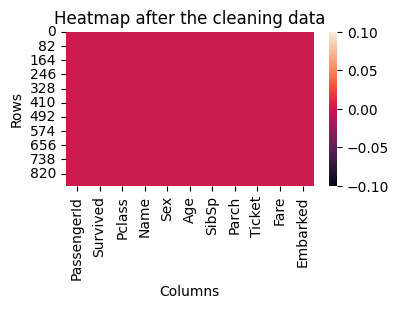

In [29]:
# Final verification sns heatmap 
plt.figure(figsize=(4,2))
sns.heatmap(data_work.isnull())
plt.title("Heatmap after the cleaning data")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

    ## What we did in this phase 
    - maked the copied of origiona data and checked the shape with if/else    conditions
    - filled age missing value with median
    - dropped the cabin column as it contained 77% of miss value 
    - filled the embarked with mode[0] most repeated value/data
    - final checked missing values with isnull() & sns heatmap

## Phase4 : Data Analysis & Visualizations
- complete with 7 required charts
- where each answers a specific questions 


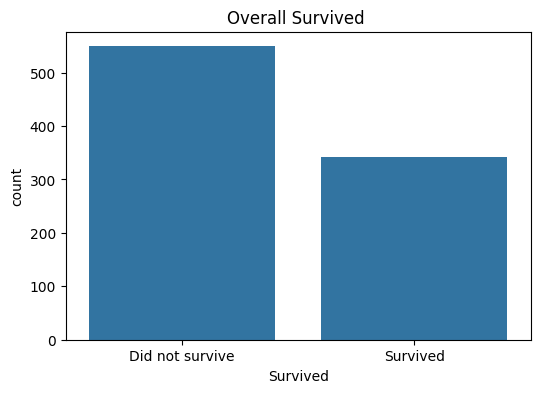

In [31]:
# Chart1 : Overall Survival Count 
# survival_cnt = data_work["Survived"].value_counts()
plt.figure(figsize=(6,4))
# plt.bar(survival_cnt.values, survival_cnt.index)
sns.countplot(x="Survived", data=data_work)
plt.title("Overall Survived ")
plt.xticks([0,1], ["Did not survive", "Survived"])

plt.show()

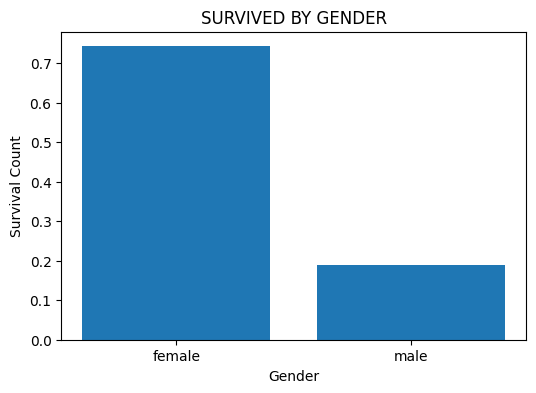

In [22]:
# Chart2 : SURVIVAL BY GENDER 
survival_gender_crt = data_work.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(6,4))
plt.title("SURVIVED BY GENDER")
plt.bar(survival_gender_crt.index, survival_gender_crt.values)
plt.xlabel("Gender")
plt.ylabel("Survival Count")

plt.show()

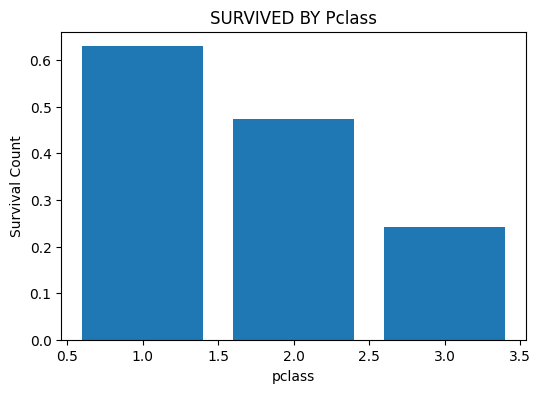

In [23]:
# Chart3 : SURVIVAL BY PASSENGER CLASS 
survival_pclass_crt = data_work.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6,4))
plt.title("SURVIVED BY Pclass")
plt.bar(survival_pclass_crt.index, survival_pclass_crt.values)
plt.xlabel("pclass")
plt.ylabel("Survival Count")
plt.show()

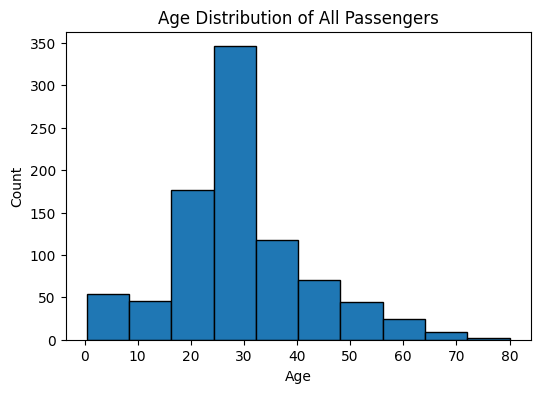

In [24]:
# Chart4 AGE DISTRIBUTION OF ALL PASSENGERS

plt.figure(figsize=(6,4))
plt.hist(data_work["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution of All Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

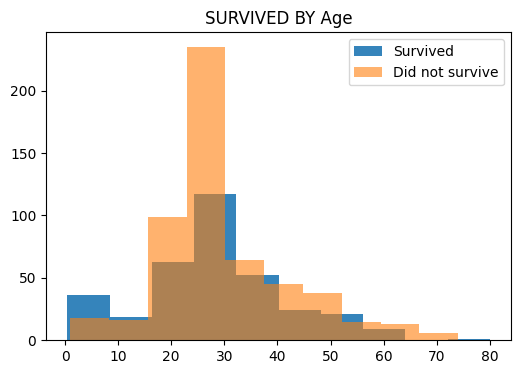

In [25]:
# Chart5 : AGE BY SURVIVAL(HISTOGRAM)
survival_age_crt = data_work.groupby("Age")["Survived"].mean()

plt.figure(figsize=(6,4))
plt.title("SURVIVED BY Age")
plt.hist(data_work[data_work["Survived"]==1]["Age"], alpha=0.9, label="Survived") 
plt.hist(data_work[data_work["Survived"]==0]["Age"], alpha=0.6, label="Did not survive")
plt.legend()
plt.show()


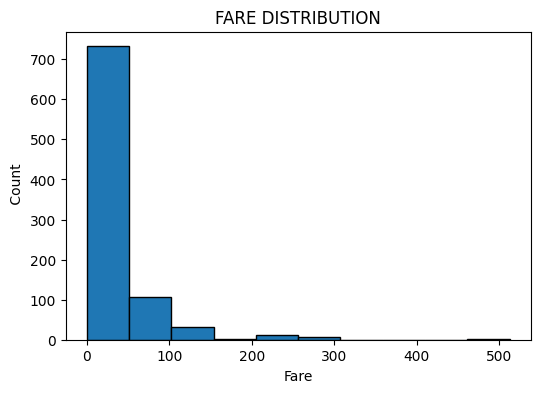

In [26]:
# Chart6 : FARE DISTRIBUTION 
fare_dis = data_work["Fare"].value_counts
plt.figure(figsize=(6,4))
plt.title("FARE DISTRIBUTION")
plt.hist(data_work["Fare"], bins=10, edgecolor="black")
plt.xlabel("Fare")
plt.ylabel(" Count")
plt.show()

<Axes: title={'center': 'Gender VS Pclass heatmap '}, xlabel='Pclass', ylabel='Sex'>

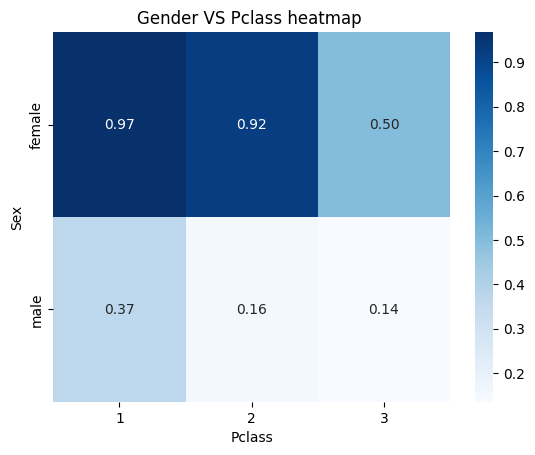

In [32]:
# Chart7 : GENDER VS CLASS HEATMAP
plt.title("Gender VS Pclass heatmap ")
pivot = data_work.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean") 
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues")

## Key Findings

1. Only 38% of passengers survived the Titanic disaster (342 out of 891).
2. Female passengers had a 74% survival rate compared to 19% for males, women were clearly prioritized during evacuation.
3. First-class passengers had the highest survival rate (63%), while third-class passengers had the lowest (24%), showing that socioeconomic status played a major role.
4. Most passengers were between 20–40 years old. Children showed relatively higher survival rates compared to adults.
5. Most fares were low, but a small number of passengers paid extremely high amounts — reflecting the wide economic inequality on board.
6. The gender × class heatmap reveals that 1st-class females had the highest survival rate (~97%), while 3rd-class males had the lowest (~14%).

## Conclusion

Gender and passenger class were the two strongest predictors of survival on the Titanic. First-class female passengers were almost guaranteed to survive, while third-class male passengers had very little chance. This analysis confirms that the evacuation followed a "women and children first" policy, but access to lifeboats was also heavily influenced by where passengers were located on the ship — which correlated directly with passenger class.